# Social Batteries: Introverts vs. Extroverts

This notebook supports the Data Visualization presentation **"Social Batteries: Introverts vs. Extroverts"**.

The objective is to analyze a Kaggle dataset about personality-related social behaviors and identify which variables most clearly distinguish introverts from extroverts.

Main research question:

**Which social behaviors most strongly distinguish introverts from extroverts?**

## 1. Import Libraries

The following libraries are used for data analysis and visualization:

- **Pandas**: data loading, cleaning checks, descriptive statistics and group comparison.
- **Matplotlib**: boxplots and radar chart generation.
- **NumPy**: numerical support for the radar chart angles.
- **IPython IFrame**: embedding the Datawrapper visualization in the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import IFrame

## 2. Load the Dataset

The dataset was downloaded from Kaggle as a CSV file.

Dataset source:  
https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data

In [2]:
personality_df = pd.read_csv("personality_datasert.csv")
personality_df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## 3. Dataset Structure and Quality Checks

This section checks the number of rows and columns, variable types, missing values, class balance and categorical values.

These checks are done because the Kaggle documentation mentions possible missing values, while the downloaded version used in this project appears complete.

In [3]:
# Number of rows and columns
personality_df.shape

(2900, 8)

In [4]:
# General information: column names, data types and non-null values
personality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
# Missing values by column
personality_df.isna().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [6]:
# Descriptive statistics for numerical variables
personality_df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [7]:
# Class balance between Extroverts and Introverts
personality_df["Personality"].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

In [8]:
# Unique values of categorical variables
categorical_cols = ["Stage_fear", "Drained_after_socializing", "Personality"]

for col in categorical_cols:
    print(f"\n{col}")
    print(personality_df[col].unique())


Stage_fear
['No' 'Yes']

Drained_after_socializing
['No' 'Yes']

Personality
['Extrovert' 'Introvert']


## 4. Variable Classification

The variables are classified according to their data type and level of measurement.

- Numerical behavioral variables are treated as **ratio variables**, because they represent counts or quantities with a meaningful zero.
- Categorical variables are treated as **nominal variables**, because they represent categories without a natural order.

In [9]:
variable_types = pd.DataFrame({
    "Variable": personality_df.columns,
    "Python_Type": [str(personality_df[col].dtype) for col in personality_df.columns]
})

variable_types

,Variable,Python_Type
0,Time_spent_Alone,float64
1,Stage_fear,object
2,Social_event_attendance,float64
3,Going_outside,float64
4,Drained_after_socializing,object
5,Friends_circle_size,float64
6,Post_frequency,float64
7,Personality,object


In [10]:
measurement_levels = pd.DataFrame({
    "Variable": [
        "Time_spent_Alone",
        "Stage_fear",
        "Social_event_attendance",
        "Going_outside",
        "Drained_after_socializing",
        "Friends_circle_size",
        "Post_frequency",
        "Personality"
    ],
    "Measurement_Level": [
        "Ratio",
        "Nominal",
        "Ratio",
        "Ratio",
        "Nominal",
        "Ratio",
        "Ratio",
        "Nominal"
    ],
    "Explanation": [
        "Daily hours spent alone, with a meaningful zero.",
        "Binary category: Yes/No.",
        "Frequency count of social event attendance.",
        "Frequency count of going outside.",
        "Binary category: Yes/No.",
        "Count of close friends.",
        "Frequency count of social media posts.",
        "Binary category: Introvert/Extrovert."
    ]
})

measurement_levels

,Variable,Measurement_Level,Explanation
0,Time_spent_Alone,Ratio,"Daily hours spent alone, with a meaningful zero."
1,Stage_fear,Nominal,Binary category: Yes/No.
2,Social_event_attendance,Ratio,Frequency count of social event attendance.
3,Going_outside,Ratio,Frequency count of going outside.
4,Drained_after_socializing,Nominal,Binary category: Yes/No.
5,Friends_circle_size,Ratio,Count of close friends.
6,Post_frequency,Ratio,Frequency count of social media posts.
7,Personality,Nominal,Binary category: Introvert/Extrovert.


## 5. Group Comparison

The analysis compares the average values of five numerical behavioral variables across the two personality groups.

This produces the summary table used for the Datawrapper comparative bar chart.

In [11]:
numeric_cols = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency"
]

summary = personality_df.groupby("Personality")[numeric_cols].mean().round(2)
summary

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
Personality,,,,,
Extrovert,2.12,5.98,4.60,9.10,5.59
Introvert,7.03,1.83,1.31,3.28,1.42


In [12]:
summary_datawrapper = summary.T.reset_index()
summary_datawrapper.columns = ["Behavior", "Extrovert", "Introvert"]

summary_datawrapper

,Behavior,Extrovert,Introvert
0,Time_spent_Alone,2.12,7.03
1,Social_event_attendance,5.98,1.83
2,Going_outside,4.60,1.31
3,Friends_circle_size,9.10,3.28
4,Post_frequency,5.59,1.42


In [13]:
# Export summary table for Datawrapper
summary_datawrapper.to_csv("datawrapper_personality_summary.csv", index=False)

## 6. Datawrapper Visualization

The comparative bar chart was created in Datawrapper using the exported summary table above.

This chart communicates the average behavioral differences between introverts and extroverts using a publication-ready visualization tool.

In [14]:
IFrame(
    "https://datawrapper.dwcdn.net/3EimF/2/",
    width=900,
    height=600
)

## 7. Python Visualization: Boxplot of Time Spent Alone

The first boxplot focuses on **Time_spent_Alone**, one of the strongest behavioral differences between the two personality groups.

The chart is saved as a PNG file for use in the presentation.

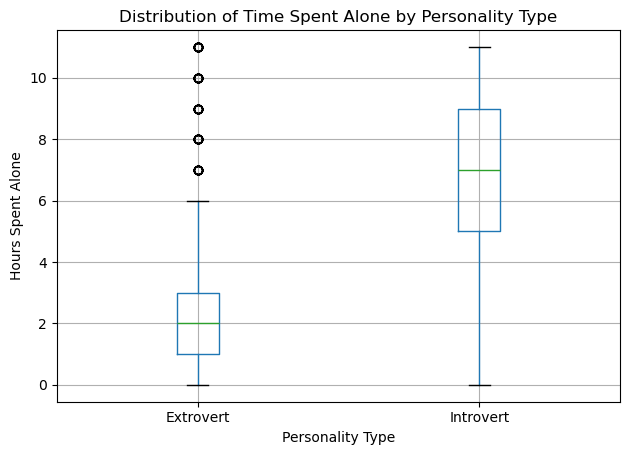

In [15]:
personality_df.boxplot(
    column="Time_spent_Alone",
    by="Personality"
)

plt.title("Distribution of Time Spent Alone by Personality Type")
plt.suptitle("")
plt.xlabel("Personality Type")
plt.ylabel("Hours Spent Alone")
plt.tight_layout()

plt.savefig("boxplot_time_spent_alone.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Python Visualization: Distribution of Key Behavioral Variables

This figure compares the distributions of three key variables:

- Time spent alone
- Social event attendance
- Friends circle size

Boxplots were selected because they show medians, quartiles, variability and outliers, not only average values.

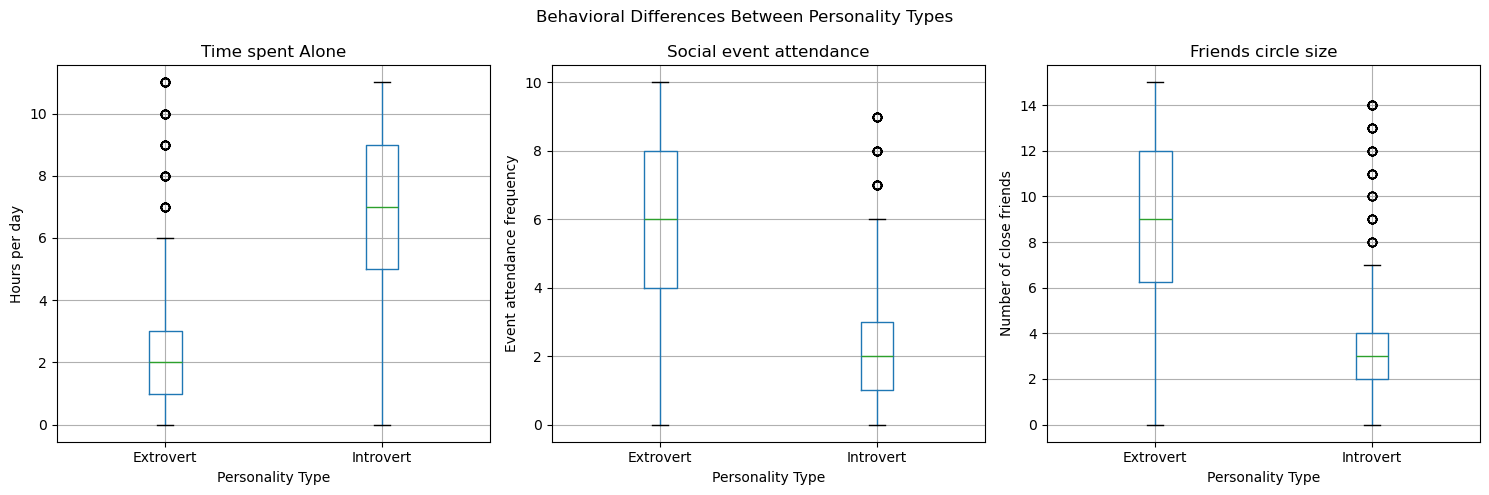

In [16]:
variables = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Friends_circle_size"
]

y_labels = [
    "Hours per day",
    "Event attendance frequency",
    "Number of close friends"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables):
    personality_df.boxplot(
        column=var,
        by="Personality",
        ax=axes[i]
    )
    axes[i].set_title(var.replace("_", " "))
    axes[i].set_xlabel("Personality Type")
    axes[i].set_ylabel(y_labels[i])

plt.suptitle("Behavioral Differences Between Personality Types")
plt.tight_layout()

plt.savefig(
    "behavior_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Cover Visualization: Radar Chart

The radar chart was created for the cover slide. It summarizes the average behavioral profile of introverts and extroverts across five variables.

Orange represents Extroverts, while blue represents Introverts.

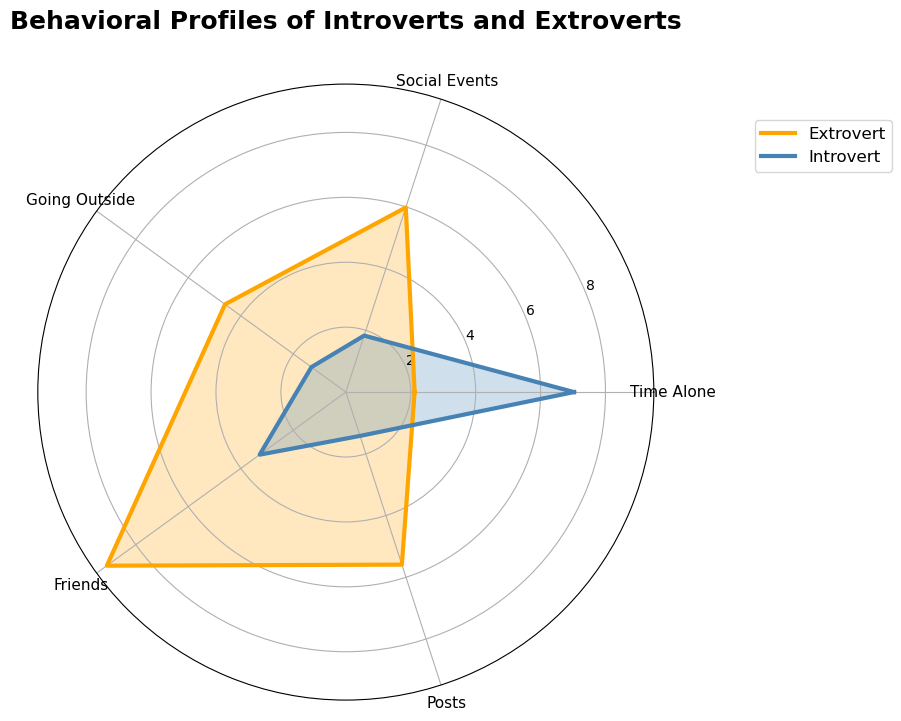

In [17]:
cover_summary = pd.DataFrame({
    "Behavior": [
        "Time Alone",
        "Social Events",
        "Going Outside",
        "Friends",
        "Posts"
    ],
    "Extrovert": [
        summary.loc["Extrovert", "Time_spent_Alone"],
        summary.loc["Extrovert", "Social_event_attendance"],
        summary.loc["Extrovert", "Going_outside"],
        summary.loc["Extrovert", "Friends_circle_size"],
        summary.loc["Extrovert", "Post_frequency"]
    ],
    "Introvert": [
        summary.loc["Introvert", "Time_spent_Alone"],
        summary.loc["Introvert", "Social_event_attendance"],
        summary.loc["Introvert", "Going_outside"],
        summary.loc["Introvert", "Friends_circle_size"],
        summary.loc["Introvert", "Post_frequency"]
    ]
})

labels = cover_summary["Behavior"]
ext = cover_summary["Extrovert"].tolist()
intro = cover_summary["Introvert"].tolist()

# Close the radar chart loop
ext += ext[:1]
intro += intro[:1]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

ax.plot(
    angles,
    ext,
    linewidth=3,
    color="orange",
    label="Extrovert"
)
ax.fill(
    angles,
    ext,
    color="orange",
    alpha=0.25
)

ax.plot(
    angles,
    intro,
    linewidth=3,
    color="steelblue",
    label="Introvert"
)
ax.fill(
    angles,
    intro,
    color="steelblue",
    alpha=0.25
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

plt.title(
    "Behavioral Profiles of Introverts and Extroverts",
    pad=40,
    fontsize=18,
    fontweight="bold"
)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.15, 0.9),
    fontsize=12
)

plt.savefig(
    "cover_radar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()